In [49]:
import numpy as np
import matplotlib.pyplot as plt
from math import sqrt

from lmfit import Model, models

In [50]:
a = 10.6407982
b = 9.17514783
heights = [5, 5, 5, 10, 10, 10, 15, 15, 15, 20, 20, 20, 25, 25, 25, 30, 30, 30]

normalised_x = [
    (height / (4.5 * 64 * 10**-4)) * (a + b)
    for height in heights
]

print(normalised_x, len(heights))

[3440.2684079861106, 3440.2684079861106, 3440.2684079861106, 6880.536815972221, 6880.536815972221, 6880.536815972221, 10320.805223958332, 10320.805223958332, 10320.805223958332, 13761.073631944442, 13761.073631944442, 13761.073631944442, 17201.342039930554, 17201.342039930554, 17201.342039930554, 20641.610447916664, 20641.610447916664, 20641.610447916664] 18


In [51]:
diam = [215.250701904, 207.690261841, 210.522613525, 246.732009888, 254.487854004, 491.828399658, 271.026489258, 265.640197754, 259.53717041, 303.691589355, 305.189880371, 314.244476318, 318.642669678, 341.954376221, 338.040924072, 361.928710938, 356.186828613, 360.57220459]
a_diam = [d / (1.91 * 64) for d, height in zip(diam, heights)]
print(len(diam))

18


In [52]:
rel_err = 0.02
err_height = [rel_err * noz for noz in heights]
print(err_height)

# measured error in D[4][3]
err_mean_diam = [35.1771659851, 45.2812614441, 32.5582427979, 31.3087768555, 34.9372062683, 83.3335037231, 29.908706665, 33.8166351318, 29.2559127808, 41.075302124, 40.7919464111, 40.9451980591, 44.2761497498, 44.4484901428, 43.842792511, 42.9053230286, 42.3033676147, 44.9048728943]
a_err_mean_diam = [e / (1.91 * 64) for e in err_mean_diam]
print(a_err_mean_diam, len(a_err_mean_diam))

[0.1, 0.1, 0.1, 0.2, 0.2, 0.2, 0.3, 0.3, 0.3, 0.4, 0.4, 0.4, 0.5, 0.5, 0.5, 0.6, 0.6, 0.6]
[0.2877713185953861, 0.3704291675728076, 0.26634688152732333, 0.25612546511371076, 0.28580829735193064, 0.6817204165829516, 0.24467201133017016, 0.27664132143160997, 0.2393317472251309, 0.3360217778468586, 0.333703750090805, 0.3349574448552029, 0.3622067224296466, 0.3636165751210733, 0.3586615879499346, 0.3509924985978403, 0.34606812512025525, 0.36735007276096204] 18


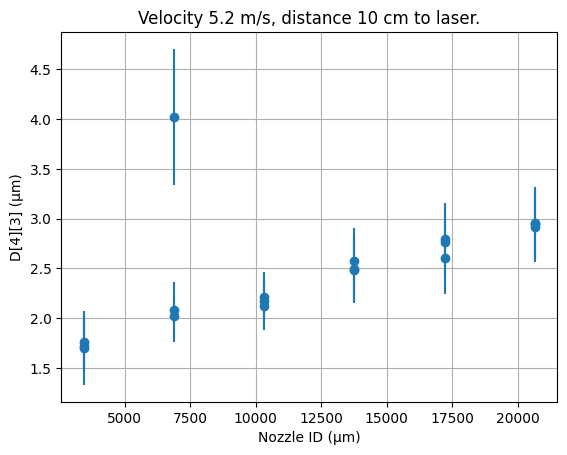

In [53]:
plt.figure()

plt.errorbar(normalised_x, a_diam, xerr=err_height, yerr=a_err_mean_diam, fmt='o')

plt.title(r"Velocity 5.2 m/s, distance 10 cm to laser.")
plt.xlabel(r"Nozzle ID (μm)")
plt.ylabel(r"D[4][3] (μm)")

# plt.xlim(6000,14000)
# plt.ylim(1,5)

plt.grid(True)
plt.show()

## fit

In [54]:
def linear_model(x, m, c):
    return m * x + c

fit_model = models.Model(linear_model)

x_fit = np.array(normalised_x)
y_fit_data = np.array(a_diam)
weights = 1 / np.array(a_err_mean_diam)

fit_result = fit_model.fit(
    y_fit_data,
    x=x_fit,
    weights=weights,
    m=1,
    c=1
)

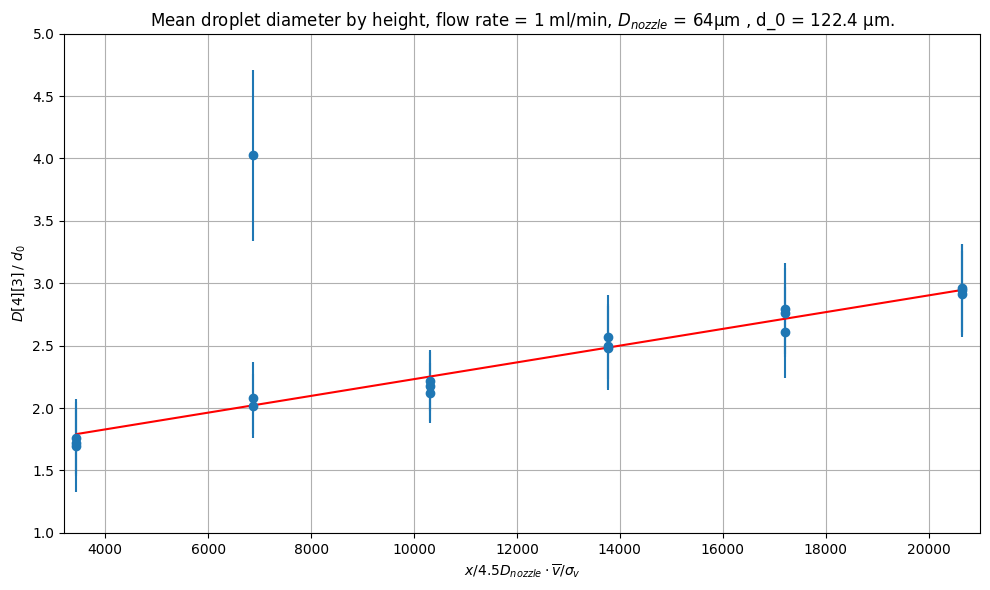

In [63]:
x = np.array(normalised_x)

idx = np.argsort(x)
x_sorted = x[idx]

y_sorted_fit = fit_result.eval(x=x_sorted)

plt.figure(figsize=(10,6))

plt.errorbar(normalised_x, a_diam,
             xerr=err_height,
             yerr=a_err_mean_diam,
             fmt='o')

plt.plot(x_sorted, y_sorted_fit, 'r-')

plt.title(r"Mean droplet diameter by height, flow rate = 1 ml/min, $D_{nozzle}$ = 64μm , d_0 = 122.4 μm.")
plt.xlabel(r"$ x / 4.5D_{nozzle} \cdot \overline{v} / \sigma_v$")
plt.ylabel(r"$D[4][3]\,/$ $d_0$")
plt.xlim(3200,21000)
plt.ylim(1,5)
plt.grid(True)
plt.tight_layout()

plt.show()

In [56]:
print(fit_result.fit_report())

[[Model]]
    Model(linear_model)
[[Fit Statistics]]
    # fitting method   = leastsq
    # function evals   = 7
    # data points      = 18
    # variables        = 2
    chi-square         = 9.44145977
    reduced chi-square = 0.59009124
    Akaike info crit   = -7.61470075
    Bayesian info crit = -5.83395723
    R-squared          = 0.27046662
[[Variables]]
    m:  6.7098e-05 +/- 1.0144e-05 (15.12%) (init = 1)
    c:  1.56070567 +/- 0.12707251 (8.14%) (init = 1)
[[Correlations]] (unreported correlations are < 0.100)
    C(m, c) = -0.8952
